In [13]:
%autoreload 2

In [35]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 13})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_35436\1284024126.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__BOUT FINDER__

In [40]:
path = f'C://Data//Imaging//260402_overlap//fish5_2//'
#if imaging fish
fish = Gafftopsail(path, sequence  = 1, filelist = ['stimulus', 'eye'])
#if behavior rig fish
#fish = Coelacanth(path, filelist = ['taileye', 'stimulus'])

In [41]:
if type(fish) == Gafftopsail:
    pass
elif type(fish) == Coelacanth:
    fish.eye_df = fish.taileye_df
    fish.eye_df.columns = ['f0_x', 'f0_vx', 'f0_y', 'f0_vy', 'f0_theta', 'f0_vtheta',
           'f0_theta_00', 'f0_theta_01', 'f0_theta_02', 'f0_theta_03',
           'f0_theta_04', 'f0_theta_05', 'f0_theta_06', 'f0_theta_07',
           'f0_theta_08', 'f0_theta_09', 'f0_theta_10', 'f0_theta_11',
           'f0_pos_x_e0', 'f0_pos_y_e0', 'f0_dim_x_e0', 'f0_dim_y_e0', 'th_e0',
           'f0_pos_x_e1', 'f0_pos_y_e1', 'f0_dim_x_e1', 'f0_dim_y_e1', 'th_e1',
           'biggest_area', 't', 'real_time', 'real_time_s']

In [42]:
fig = bhfd.saccade_finder(fish, time_window_s =1, min_interval_s = 0.1, min_saccade_s = 0.1, startframe = 16918, endframe = 36918,
               lowpass = True, std_scale =1)
fish.saccade_df.to_csv(fish.path + 'Eye//eye_saccade_df.csv')
fig.savefig(fish.path + '//Graphs//saccade_example.png')

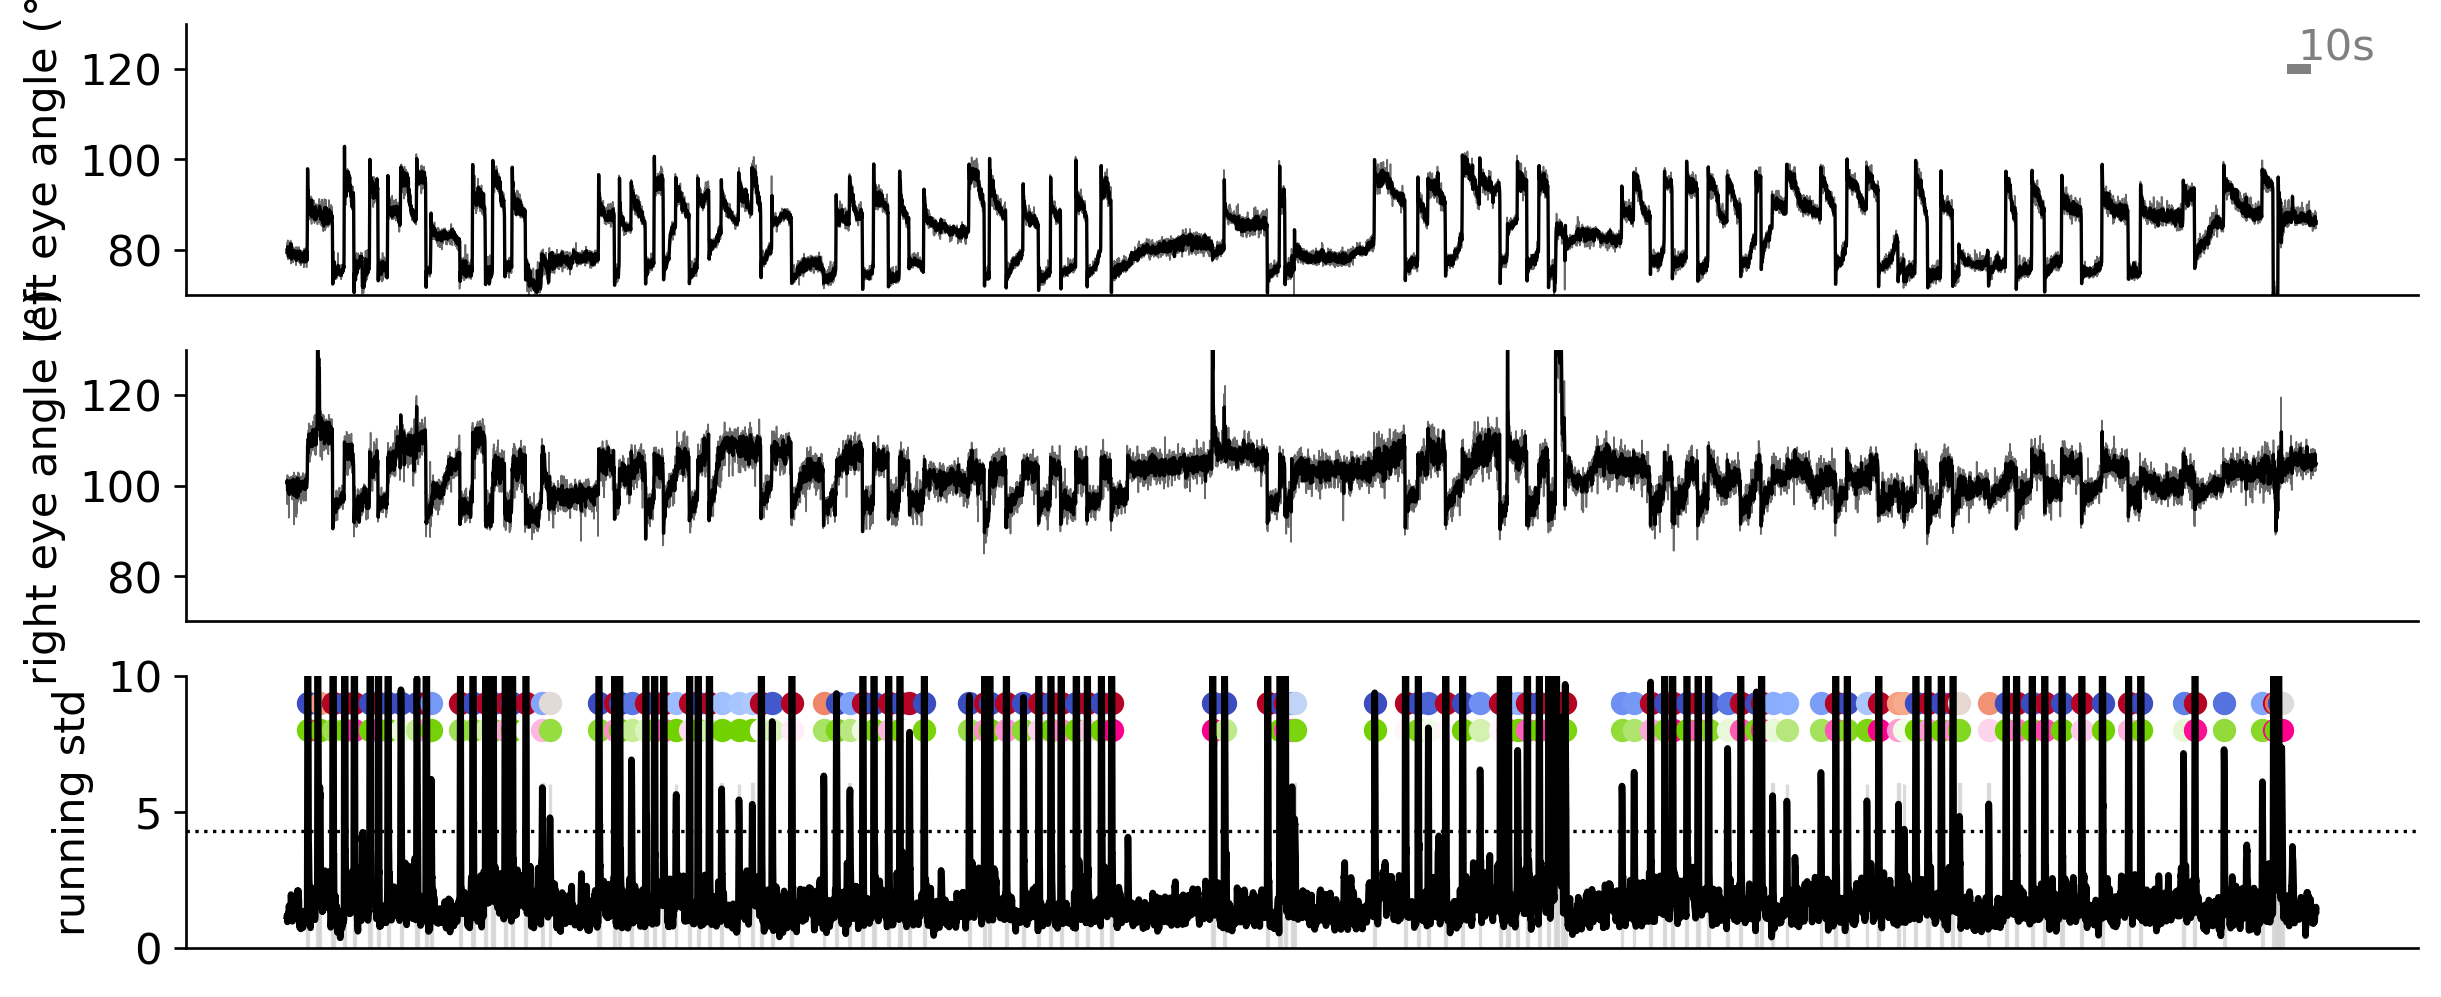

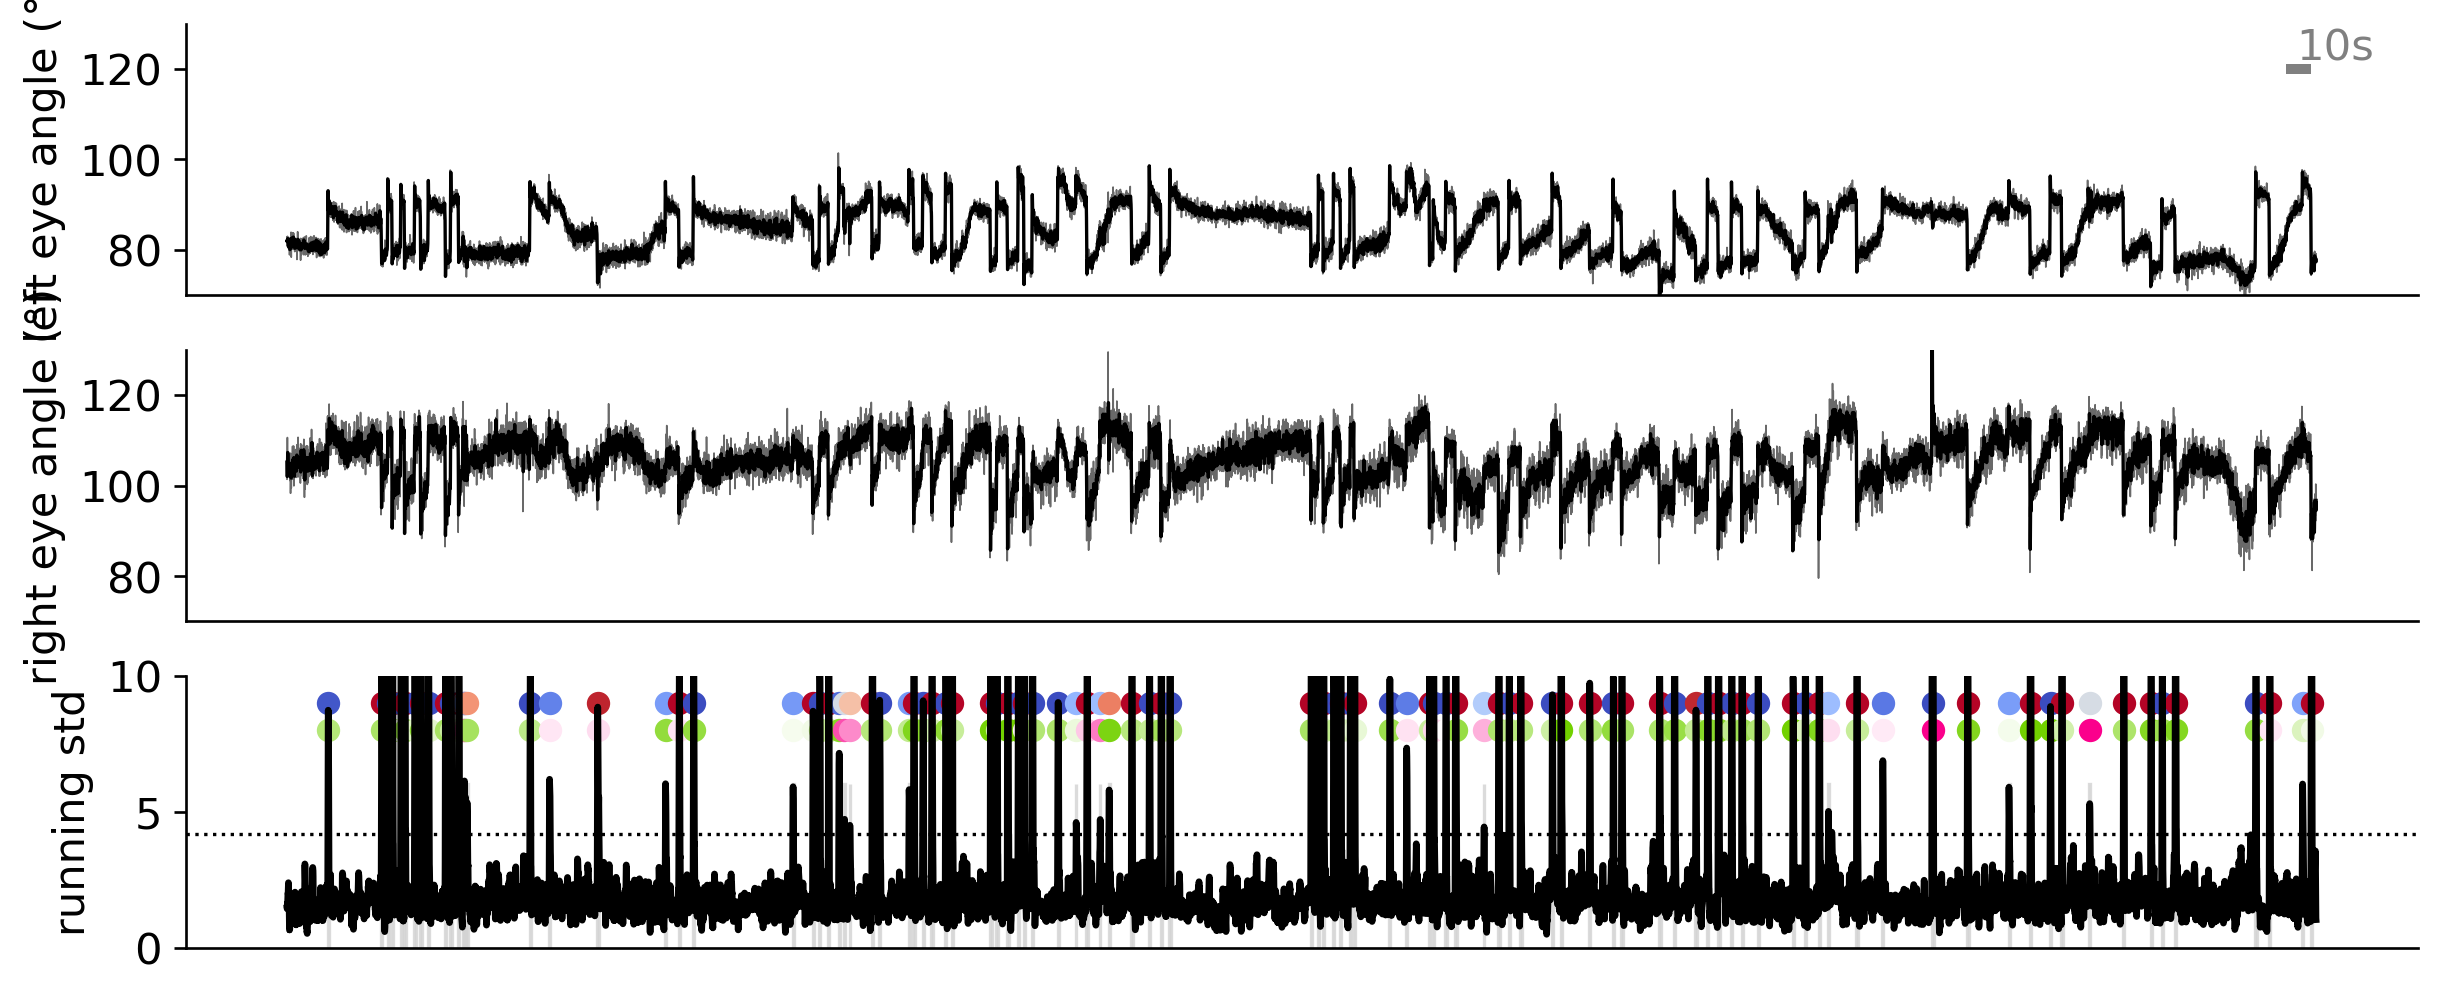

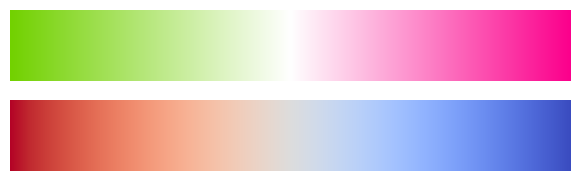

In [43]:
#plot associated cmaps
cmaps = [cmap_conv, 'coolwarm_r']
fig, axes = plt.subplots(len(cmaps), 1, figsize=(6, 2))
for ax, name in zip(axes, cmaps):
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect="auto", cmap=name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [44]:
fish.stimulus_df.stim_name.unique()

TypeError: unhashable type: 'list'

In [45]:
stim_order = ['left', 'right', 'dot_l', 'dot_r', 'stationary']

fig = bhfd.plot_saccade_distribution(fish, stimorder = stim_order)
fig.savefig(fish.path + '//Graphs//saccade_stats.png')

C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:202: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)


In [30]:
stim_matrix =  np.array([['skip', 'dot_l', 'dot_r'],
                        ['forward', "['dot_l', 'forward']", "['dot_r', 'forward']"],
                        ['left', "['dot_l', 'left']", "['dot_r', 'left']"],
                        ['right', "['dot_l', 'right']", "['dot_r', 'right']"],
                        ['backward', "['dot_l', 'backward']", "['dot_r', 'backward']"]])
stim_matrix = np.array([['dot_l_3', 'dot_r_3'], ['dot_l_5', 'dot_r_5'], ['dot_l_10', 'dot_r_10'], ['dot_l_20', 'dot_r_20'],
                                                        ['dot_l_40', 'dot_r_40']])
stim_matrix = np.array([['dot_l_aaa', 'dot_r_aaa', 'dot_l_aab', 'dot_r_aab', 'dot_l_aba', 'dot_r_aba', 'dot_l_abb', 'dot_r_abb'],
                       ['dot_l_baa', 'dot_r_baa', 'dot_l_bab',  'dot_r_bab', 'dot_l_bba', 'dot_r_bba',  'dot_l_bbb', 'dot_r_bbb'],
                       ['dot_l_caa', 'dot_r_caa','dot_l_cab', 'dot_r_cab', 'dot_l_cba', 'dot_r_cba', 'dot_l_cbb', 'dot_r_cbb']])
stim_matrix = np.array([['left', 'right'],
                         ['dot_l', 'dot_r']])
fig = bhfd.plot_all_saccades(fish,stim_matrix)
fig.savefig(fish.path + '//Graphs//saccade_all.png')

IndexError: list index out of range

In [24]:
plt.close()

__combine all fish__

In [39]:
path = 'C://Data//Imaging//251030_dotsweep_embed//25'
for fish in [ r"C:\Data\251030_dotsweep_embed\251101_f9",
r"C:\Data\251030_dotsweep_embed\251101_f10",
r"C:\Data\251030_dotsweep_embed\251101_f11",
r"C:\Data\251030_dotsweep_embed\251101_f11_2",
r"C:\Data\251030_dotsweep_embed\251101_f12",
r"C:\Data\251030_dotsweep_embed\251101_f12_2",
r"C:\Data\251030_dotsweep_embed\251101_f13",
r"C:\Data\251030_dotsweep_embed\251101_f14",
r"C:\Data\251030_dotsweep_embed\251101_f15",
r"C:\Data\251030_dotsweep_embed\251030_f1",
r"C:\Data\251030_dotsweep_embed\251030_f2",
r"C:\Data\251030_dotsweep_embed\251030_f3",
r"C:\Data\251030_dotsweep_embed\251030_f4",
r"C:\Data\251030_dotsweep_embed\251030_f5",
r"C:\Data\251030_dotsweep_embed\251030_f6",
r"C:\Data\251030_dotsweep_embed\251030_f7",
r"C:\Data\251030_dotsweep_embed\251030_f8",
r"C:\Data\251030_dotsweep_embed\251030_f8100"]:
    fishpath = fish + '//'
    #if imaging fish
    #fish = Gafftopsail(fishpath, sequence  = 5, filelist = ['stimulus', 'eye'])
    #if behavior rig fish
    fish = Coelacanth(fishpath, filelist=['taileye', 'stimulus'])
    if type(fish) == Gafftopsail:
        pass
    elif type(fish) == Coelacanth:
        fish.eye_df = fish.taileye_df
        fish.eye_df.columns = ['f0_x', 'f0_vx', 'f0_y', 'f0_vy', 'f0_theta', 'f0_vtheta',
                               'f0_theta_00', 'f0_theta_01', 'f0_theta_02', 'f0_theta_03',
                               'f0_theta_04', 'f0_theta_05', 'f0_theta_06', 'f0_theta_07',
                               'f0_theta_08', 'f0_theta_09', 'f0_theta_10', 'f0_theta_11',
                               'f0_pos_x_e0', 'f0_pos_y_e0', 'f0_dim_x_e0', 'f0_dim_y_e0', 'th_e0',
                               'f0_pos_x_e1', 'f0_pos_y_e1', 'f0_dim_x_e1', 'f0_dim_y_e1', 'th_e1',
                               'biggest_area', 't', 'real_time', 'real_time_s']
    fig = bhfd.saccade_finder(fish, time_window_s=1, min_interval_s=0.1, min_saccade_s=0.1, startframe=36918,
                              endframe=56918,
                              lowpass=True, std_scale=1)
    fish.saccade_df.to_csv(fish.path + 'Eye//eye_saccade_df.csv')
    fig.savefig(fish.path + '//Graphs//saccade_example.png')
    plt.close(fig)
    #plot associated cmaps
    fig = bhfd.plot_saccade_distribution(fish,
                                         stimorder=['dot_l_3', 'dot_r_3', 'dot_l_5', 'dot_r_5', 'dot_l_10', 'dot_r_10',
                                                    'dot_l_20', 'dot_r_20',
                                                    'dot_l_40', 'dot_r_40', ])
    fig.savefig(fish.path + '//Graphs//saccade_stats.png')
    plt.close(fig)
    stim_matrix = np.array([['skip', 'dot_l', 'dot_r'],
                            ['forward', "['dot_l', 'forward']", "['dot_r', 'forward']"],
                            ['left', "['dot_l', 'left']", "['dot_r', 'left']"],
                            ['right', "['dot_l', 'right']", "['dot_r', 'right']"],
                            ['backward', "['dot_l', 'backward']", "['dot_r', 'backward']"]])
    stim_matrix = np.array(
        [['dot_l_3', 'dot_r_3'], ['dot_l_5', 'dot_r_5'], ['dot_l_10', 'dot_r_10'], ['dot_l_20', 'dot_r_20'],
         ['dot_l_40', 'dot_r_40']])
    fig = bhfd.plot_all_saccades(fish, stim_matrix)
    fig.savefig(fish.path + '//Graphs//saccade_all.png')
    plt.close(fig)

C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(stimorder, rotation =0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat